In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn nltk wordcloud

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

In [4]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
def load_data(filepath):
    data = pd.read_csv(filepath, sep=':::', names=['ID', 'TITLE', 'GENRE', 'DESCRIPTION'], 
                       engine='python', encoding='utf-8')
    return data

train_data = load_data('train_data.txt')

print("Dataset Shape:", train_data.shape)
print(train_data.head())
print(train_data.info())
print(train_data.isnull().sum())

Dataset Shape: (54214, 4)
   ID                               TITLE       GENRE  \
0   1       Oscar et la dame rose (2009)       drama    
1   2                       Cupid (1997)    thriller    
2   3   Young, Wild and Wonderful (1980)       adult    
3   4              The Secret Sin (1915)       drama    
4   5             The Unrecovered (2007)       drama    

                                         DESCRIPTION  
0   Listening in to a conversation between his do...  
1   A brother and sister with a past incestuous r...  
2   As the bus empties the students for their fie...  
3   To help their unemployed father make ends mee...  
4   The film's title refers not only to the un-re...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54214 non-null  int64 
 1   TITLE        54214 non-null  object
 2   GENRE        54214 non-n

In [16]:
train_data = train_data.drop_duplicates(subset=['DESCRIPTION'])
train_data = train_data.dropna(subset=['DESCRIPTION', 'GENRE'])
train_data.shape
train_data.head()

,ID,TITLE,GENRE,DESCRIPTION,DESCRIPTION_CLEAN
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...,listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...,a brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...,as the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...,to help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...,the film's title refers not only to the un-rec...


In [17]:
def preprocess_text(text):
    if isinstance(text, float):
        return ""
    text = text.lower()
    text = ' '.join(text.split())
    return text

train_data['DESCRIPTION_CLEAN'] = train_data['DESCRIPTION'].apply(preprocess_text)
train_data[['DESCRIPTION','DESCRIPTION_CLEAN']].head()

,DESCRIPTION,DESCRIPTION_CLEAN
0,Listening in to a conversation between his do...,listening in to a conversation between his doc...
1,A brother and sister with a past incestuous r...,a brother and sister with a past incestuous re...
2,As the bus empties the students for their fie...,as the bus empties the students for their fiel...
3,To help their unemployed father make ends mee...,to help their unemployed father make ends meet...
4,The film's title refers not only to the un-re...,the film's title refers not only to the un-rec...


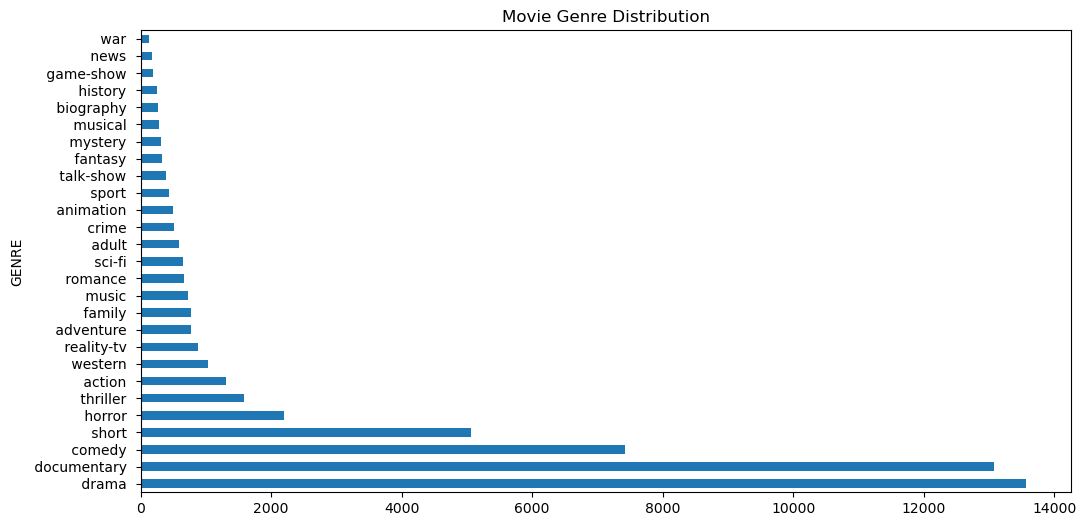

In [8]:
plt.figure(figsize=(12, 6))
train_data['GENRE'].value_counts().plot(kind='barh')
plt.title('Movie Genre Distribution')
plt.show()

In [21]:
print("X_train size:", X_train.shape)
print("X_test size:", X_test.shape)
print("y_train size:", y_train.shape)
print("y_test size:", y_test.shape)


X_train size: (43268,)
X_test size: (10818,)
y_train size: (43268,)
y_test size: (10818,)


In [26]:
print(tfidf_vectorizer.get_feature_names_out()[:20])



['000' '10' '10 000' '10 year' '10 years' '100' '11' '12' '12 year' '13'
 '14' '15' '15 years' '16' '16 year' '17' '17 year' '18' '19' '1930']


In [30]:
# Cell 11: SVM
from sklearn.svm import LinearSVC

svm_model = LinearSVC(max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# IMPORTANT LINE (this was missing)
y_pred_svm = svm_model.predict(X_test_tfidf)


                     Accuracy  Precision    Recall  F1-Score
Naive Bayes          0.519689   0.516833  0.519689  0.441450
Logistic Regression  0.579590   0.553499  0.579590  0.538881
SVM                  0.565631   0.532798  0.565631  0.540719


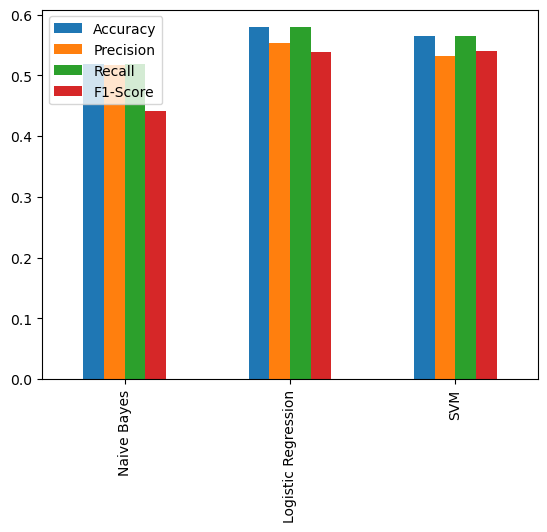

In [32]:
comparison_df = pd.DataFrame({
    'Naive Bayes': [
        accuracy_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted')
    ],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted')
    ],
    'SVM': [
        accuracy_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T

print(comparison_df)
comparison_df.plot(kind='bar')
plt.show()


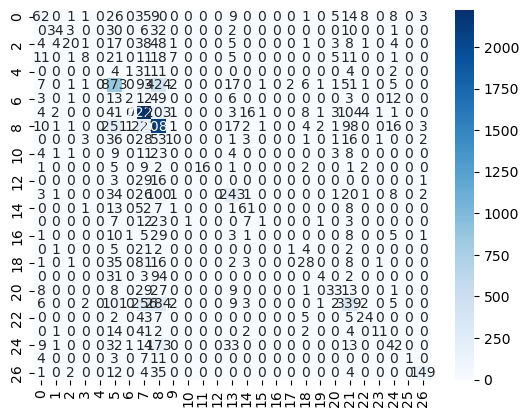

In [33]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [34]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

for genre in lr_model.classes_:
    idx = list(lr_model.classes_).index(genre)
    coef = lr_model.coef_[idx]
    top_features = feature_names[np.argsort(coef)[-10:]]
    print(f"{genre}: {top_features}")

 action : ['stop' 'killed' 'singh' 'assassin' 'fighter' 'revenge' 'martial' 'police'
 'fight' 'action']
 adult : ['adult' 'bondage' 'bound' 'lesbian' 'sexy' 'girls' 'hot' 'gagged'
 'sexual' 'sex']
 adventure : ['blonde' 'bound' 'evil' 'ladies' 'treasure' 'tied' 'gagged' 'jungle'
 'adventure' 'bondage']
 animation : ['monster' 'earth' 'animals' 'friends' 'magical' 'evil' 'adventure'
 'animation' 'adventures' 'animated']
 biography : ['american' 'born' 'author' 'legend' 'age' 'story' 'great' 'film'
 'documentary' 'life']
 comedy : ['characters' 'comic' 'awkward' 'decides' 'funny' 'eccentric' 'sketches'
 'comedic' 'hilarious' 'comedy']
 crime : ['crimes' 'killed' 'boss' 'killer' 'case' 'drug' 'criminal' 'murder'
 'police' 'crime']
 documentary : ['people' 'follows' 'history' 'explores' 'documents' 'film' 'portrait'
 'years' 'interviews' 'documentary']
 drama : ['wife' 'true story' 'story' 'relationship' 'tragedy' 'young' 'friendship'
 'life' 'lives' 'drama']
 family : ['science' 'year' 'h

In [35]:
def predict_movie_genre(description, model, vectorizer):
    desc_clean = preprocess_text(description)
    desc_vec = vectorizer.transform([desc_clean])
    return model.predict(desc_vec)[0], model.predict_proba(desc_vec)[0]

In [36]:
descriptions = [
    "A group of detectives investigate a murder mystery",
    "A romantic love story set in Paris",
    "A superhero saves the world from aliens"
]

for d in descriptions:
    print(predict_movie_genre(d, lr_model, tfidf_vectorizer))

(' mystery ', array([0.05134834, 0.00605166, 0.01622466, 0.00613251, 0.003931  ,
       0.01235359, 0.06149492, 0.0315225 , 0.02918866, 0.00801951,
       0.00481962, 0.00270072, 0.00518025, 0.07343451, 0.00361699,
       0.00321165, 0.48127546, 0.00263105, 0.0070072 , 0.00308903,
       0.01518969, 0.02603893, 0.00329755, 0.00421526, 0.11899544,
       0.00282834, 0.01620096]))
(' romance ', array([0.00290015, 0.00214009, 0.00755118, 0.00449676, 0.00273178,
       0.09627288, 0.00422709, 0.00839053, 0.24464495, 0.00257406,
       0.00440638, 0.00081309, 0.00245341, 0.00167604, 0.00405586,
       0.01086968, 0.00340421, 0.00077269, 0.00208376, 0.55314761,
       0.00321623, 0.0246318 , 0.00174791, 0.00136326, 0.00686135,
       0.00086345, 0.00170377]))
(' documentary ', array([0.05358778, 0.008325  , 0.03303972, 0.02170001, 0.00767405,
       0.06885507, 0.0062468 , 0.22488408, 0.05258819, 0.01455824,
       0.02359437, 0.00355445, 0.01048846, 0.01535173, 0.01407721,
       0.00746025

In [37]:
import joblib
joblib.dump(lr_model, 'genre_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf.pkl')

['tfidf.pkl']

In [38]:
model = joblib.load('genre_model.pkl')
vectorizer = joblib.load('tfidf.pkl')

print(predict_movie_genre(
    "An action-packed thriller with car chases", model, vectorizer
))

(' thriller ', array([0.17637933, 0.0108754 , 0.00760774, 0.00421981, 0.00188724,
       0.01467848, 0.00544969, 0.00797266, 0.00535146, 0.00833024,
       0.00293721, 0.00147896, 0.00178168, 0.00660647, 0.00182689,
       0.00158894, 0.00420453, 0.00273895, 0.01105064, 0.00348443,
       0.00948975, 0.0451194 , 0.01001986, 0.00308586, 0.64785547,
       0.00141429, 0.00256462]))


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [41]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [46]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [47]:
def predict_genre(description):
    description = preprocess_text(description)
    vector = tfidf.transform([description])
    prediction = lr_model.predict(vector)
    return prediction[0]


In [48]:
new_movie = "A young hero fights against evil forces to save the world"
print("Predicted Genre:", predict_genre(new_movie))


Predicted Genre:  action 


In [51]:
def predict_genre(description, model, vectorizer):
    description = preprocess_text(description)
    vector = vectorizer.transform([description])
    return model.predict(vector)[0]

new_movie = "A young hero fights against evil forces to save the world"
print("Predicted Genre:", predict_genre(new_movie, lr_model, tfidf))


Predicted Genre:  action 
